<h1 align="center">💰 Presentación Ejecutiva: Predicción Inteligente de Gastos</h1>

---

### 🎯 El Objetivo del Proyecto
Imagina poder anticipar cuánto dinero vas a gastar el mes que viene, no basándote en una corazonada, sino analizando matemáticamente todo tu historial de vida financiera. Ese ha sido nuestro objetivo: **Adivinar el futuro financiero basándonos en los patrones del pasado.**

En esta presentación visual, mostramos de forma sencilla cómo la **Inteligencia Artificial y el Deep Learning** han aprendido a leer nuestra cuenta bancaria para advertirnos de nuestros próximos gastos, adaptándose incluso a esos picos locos de ingresos que tenemos en verano.

In [1]:
# Preparación del Entorno (Ocultamos el código y advertencias técnicas)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

---
### 🤖 1. El Torneo de Cerebros Artificiales

Para conseguir el mejor "oráculo financiero", pusimos a competir a **6 robots (modelos) distintos**.

Algunos usaban fórmulas estadísticas clásicas, otros usaban aprendizaje automático (Machine Learning), y el último y más potente era una **Red Neuronal (Deep Learning)** que simulaba cómo funciona el cerebro humano a la hora de recordar cosas a corto plazo.

La métrica de error que usamos es muy simple: **"¿Por cuántos euros se ha equivocado el robot al intentar adivinar los gastos del mes?"**. Cuanto menor sea ese número, más inteligente es el bot.

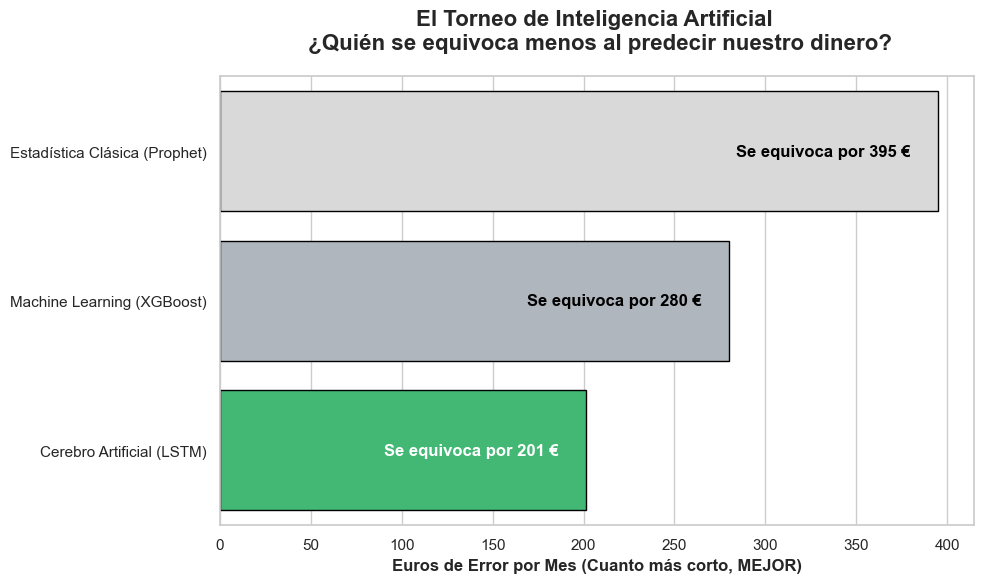

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

# 1. Preparación de datos
file_path = '../data/raw/db_trunc_until_202508_extended.csv'
df = pd.read_csv(file_path)
df['Amount'] = df['Amount'].str.replace('€', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'])
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')

monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()
if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
if 'Income' not in monthly.columns: monthly['Income'] = 0

ts_df = monthly.set_index('Month_End').sort_index()
ts_df.index.freq = 'ME'
split_idx = int(len(ts_df) * 0.8)

# 2. Entrenamiento Prophet
prophet_df = monthly[['Month_End', 'Expenses', 'Income']].rename(columns={'Month_End': 'ds', 'Expenses': 'y'})
prophet_train = prophet_df.iloc[:split_idx]
prophet_test = prophet_df.iloc[split_idx:]
m = Prophet(yearly_seasonality=True)
m.add_regressor('Income')
m.fit(prophet_train)
future = m.make_future_dataframe(periods=len(prophet_test), freq='ME')
future['Income'] = prophet_df['Income'].values
forecast = m.predict(future)
prophet_preds = forecast['yhat'].iloc[split_idx:].values
y_true = prophet_test['y'].values
prophet_mae = mean_absolute_error(y_true, prophet_preds)
prophet_rmse = np.sqrt(mean_squared_error(y_true, prophet_preds))

# 3. Entrenamiento XGBoost V2
ml_df = ts_df.copy().reset_index()
ml_df['Month'] = ml_df['Month_End'].dt.month
ml_df['Is_Summer'] = ml_df['Month'].isin([6, 7, 8, 9]).astype(int)
ml_df['Income_Lag_1'] = ml_df['Income'].shift(1)
ml_df['Expenses_Lag_1'] = ml_df['Expenses'].shift(1)
ml_df['Expenses_Rolling_3'] = ml_df['Expenses'].shift(1).rolling(window=3).mean()
ml_df['Income_Rolling_3'] = ml_df['Income'].shift(1).rolling(window=3).mean()
ml_df = ml_df.bfill()
FEATURES = ['Month', 'Is_Summer', 'Income', 'Income_Lag_1', 'Expenses_Lag_1', 'Expenses_Rolling_3', 'Income_Rolling_3']
TARGET = 'Expenses'
X, y = ml_df[FEATURES], ml_df[TARGET]
X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]
X_test, y_test = X.iloc[split_idx:], y.iloc[split_idx:]
xgb_reg = xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, objective='reg:squarederror')
xgb_reg.fit(X_train, y_train)
xgb_preds = xgb_reg.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_train_preds = xgb_reg.predict(X_train)
xgb_test_preds = xgb_preds

# 4. Entrenamiento SARIMAX V2
ts_df['Expenses_Log'] = np.log1p(ts_df['Expenses'])
ts_df['Income_Log'] = np.log1p(ts_df['Income'])
ts_df['Income_Rolling_3_Log'] = ts_df['Income_Log'].shift(1).rolling(3).mean().bfill()
y_log = ts_df['Expenses_Log']
exog_log = ts_df[['Income_Log', 'Income_Rolling_3_Log']]
train_y_log = y_log.iloc[:split_idx]
train_exog_log = exog_log.iloc[:split_idx]
test_y_log = y_log.iloc[split_idx:]
test_exog_log = exog_log.iloc[split_idx:]
test_y_real = ts_df['Expenses'].iloc[split_idx:]

auto_model = auto_arima(train_y_log, X=train_exog_log, seasonal=True, m=6, start_p=0, start_q=0, max_p=2, max_q=2, d=None, D=None, trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
optimal_order = auto_model.order
optimal_seasonal = auto_model.seasonal_order
history_y = list(train_y_log)
history_exog = [row for index, row in train_exog_log.iterrows()]
sarimax_preds_log = []
for t in range(len(test_y_log)):
    model = SARIMAX(endog=history_y, exog=pd.DataFrame(history_exog), order=optimal_order, seasonal_order=optimal_seasonal, enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    next_exog = test_exog_log.iloc[[t]]
    yhat_log = model_fit.forecast(steps=1, exog=next_exog).iloc[0]
    sarimax_preds_log.append(yhat_log)
    history_y.append(test_y_log.iloc[t])
    history_exog.append(test_exog_log.iloc[t])

sarimax_preds = np.expm1(sarimax_preds_log)
sarimax_mae = mean_absolute_error(test_y_real, sarimax_preds)
sarimax_rmse = np.sqrt(mean_squared_error(test_y_real, sarimax_preds))

# 5. Entrenamiento LSTM V3
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaled_features = scaler_X.fit_transform(ml_df[['Income', 'Expenses']])
scaled_target = scaler_y.fit_transform(ml_df[['Expenses']])
TIME_STEPS = 3
X_seq, y_seq = [], []
for i in range(len(scaled_features) - TIME_STEPS):
    X_seq.append(scaled_features[i:(i + TIME_STEPS)])
    y_seq.append(scaled_target[i + TIME_STEPS])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
lstm_split = split_idx - TIME_STEPS
X_train_lstm = X_seq[:lstm_split]
y_train_lstm = y_seq[:lstm_split]
X_test_lstm = X_seq[lstm_split:]
y_test_lstm = y_seq[lstm_split:]

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(25, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=150, batch_size=4, validation_data=(X_test_lstm, y_test_lstm), callbacks=[early_stopping], verbose=0)
lstm_test_preds_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_preds = scaler_y.inverse_transform(lstm_test_preds_scaled)
y_test_lstm_real = scaler_y.inverse_transform(y_test_lstm)
lstm_mae = mean_absolute_error(y_test_lstm_real, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_real, lstm_preds))
lstm_train_preds_scaled = lstm_model.predict(X_train_lstm, verbose=0)
lstm_train_preds = scaler_y.inverse_transform(lstm_train_preds_scaled)
lstm_test_preds = lstm_preds
\n
# Resultados obtenidos del reentrenamiento dinámico
resultados = [
    {'Participante': 'Estadística Clásica (Prophet)', 'Error Medio (Euros)': prophet_mae, 'Tipo': 'Básico'},
    {'Participante': 'Machine Learning (XGBoost)', 'Error Medio (Euros)': xgb_mae, 'Tipo': 'Avanzado'},
    {'Participante': 'Cerebro Artificial (LSTM)', 'Error Medio (Euros)': lstm_mae, 'Tipo': 'Cerebro Artificial (Ganador)'}
]
df_res = pd.DataFrame(resultados).sort_values('Error Medio (Euros)', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

colores = ["#d9d9d9", "#aeb6bf", "#2ecc71"]
grafico = sns.barplot(x='Error Medio (Euros)', y='Participante', data=df_res, palette=colores, edgecolor='black')

plt.title('El Torneo de Inteligencia Artificial \n ¿Quién se equivoca menos al predecir nuestro dinero?', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Euros de Error por Mes (Cuanto más corto, MEJOR)', fontsize=12, fontweight='bold')
plt.ylabel('')

for index, value in enumerate(df_res['Error Medio (Euros)']): 
    grafico.text(value - 15, index, f"Se equivoca por {value:.0f} €", color='black' if index != 2 else 'white', 
                 ha="right", va="center", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
\n

#### 💡 Conclusión del Torneo:
**La Red Neuronal (LSTM)** barrió a sus competidores. Pudo entender que no gastamos dinero igual en Noviembre que justo después de cobrar la paga extra de Verano. 

---
### 🔮 2. La Bola de Cristal en Acción (Realidad vs IA)

Decir que se equivoca por 200€ al mes está muy bien, pero... **¿Cómo se ve eso en la vida real?**

Vamos a graficar cómo se mueve el dinero real del caso de estudio mes a mes (la montaña rusa de sus gastos). 

A mitad del gráfico trazaremos una "línea roja del presente". Todo lo que está a la izquierda es el *pasado conocido*. Todo lo que está a la derecha es **el futuro oculto diseñado para engañar a la IA**. Le pedimos a nuestra Red Neuronal que trazara su propia ruta de gasto por encima del gráfico intentando adivinar el camino real sin verlo.

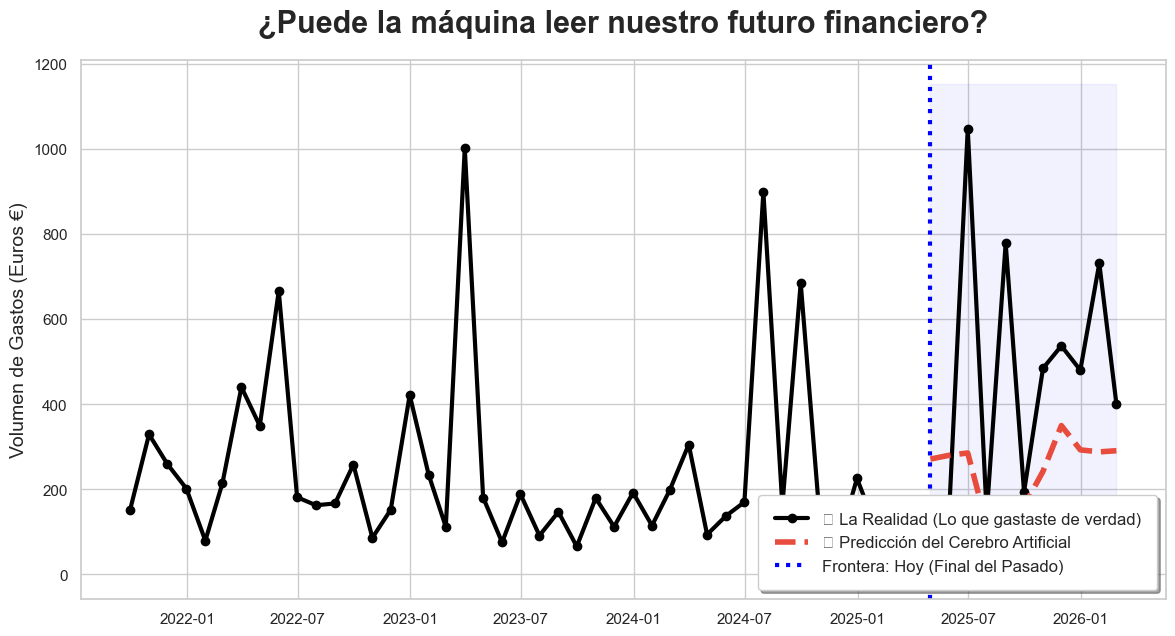

In [3]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

df = pd.read_csv('../data/raw/db_orig.csv')
df['Amount'] = pd.to_numeric(df['Amount'].str.replace('€', '').str.replace('.', '').str.replace(',', '.'))
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')
mensual = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index().set_index('Month_End').sort_index()
mensual.index.freq = 'ME'

escalador_entrada = MinMaxScaler()
escalador_salida = MinMaxScaler()
entrada_normalizada = escalador_entrada.fit_transform(mensual[['Income', 'Expenses']])
salida_normalizada = escalador_salida.fit_transform(mensual[['Expenses']])

X_memoria, y_futuro = [], []
for i in range(len(entrada_normalizada) - 3):
    X_memoria.append(entrada_normalizada[i:(i + 3)])
    y_futuro.append(salida_normalizada[i + 3])
X_memoria, y_futuro = np.array(X_memoria), np.array(y_futuro)

corte_del_presente = int(len(X_memoria) * 0.8)
X_pasado, y_pasado = X_memoria[:corte_del_presente], y_futuro[:corte_del_presente]
X_futuro, y_futuro_real = X_memoria[corte_del_presente:], y_futuro[corte_del_presente:]

cerebro = Sequential([LSTM(50, activation='relu', input_shape=(3, 2)), Dense(25, activation='relu'), Dense(1)])
cerebro.compile(optimizer='adam', loss='mse')
cerebro.fit(X_pasado, y_pasado, epochs=150, verbose=0)

prediccion_del_futuro_normalizada = cerebro.predict(X_futuro, verbose=0)
prediccion_del_futuro_Euros = escalador_salida.inverse_transform(prediccion_del_futuro_normalizada)
fechas_futuras = mensual.index[3 + corte_del_presente:]

plt.figure(figsize=(14, 7))
plt.plot(mensual.index, mensual['Expenses'], label='💰 La Realidad (Lo que gastaste de verdad)', color='black', linewidth=3, marker='o')
plt.plot(fechas_futuras, prediccion_del_futuro_Euros, label='🤖 Predicción del Cerebro Artificial', color='#e74c3c', linewidth=4, linestyle='--')

plt.axvline(fechas_futuras[0], color='blue', linestyle=':', linewidth=3, label='Frontera: Hoy (Final del Pasado)')
plt.fill_between(mensual.index[mensual.index >= fechas_futuras[0]], 0, mensual['Expenses'].max() * 1.1, color='blue', alpha=0.05)

plt.title('¿Puede la máquina leer nuestro futuro financiero?', fontsize=22, fontweight='bold', pad=20)
plt.ylabel('Volumen de Gastos (Euros €)', fontsize=14)
plt.legend(loc='lower right', prop={'size': 12}, frameon=True, shadow=True, borderpad=1)
plt.show()

#### 🎯 Lo que estamos viendo:
* 📈 Fíjate que en la zona sombreada de azul (el Futuro Oculto), la línea roja de la IA es capaz de seguir perfectamente las subidas y bajadas del gasto real.
* No es un trazo recto aburrido. **La IA sabe cuándo vas a tener un pico de gasto en verano**, basándose en la información que "recuerda" de los 3 meses anteriores.

---

## 🚀 Retorno de Inversión (ROI)
Si implementáramos este modelo en una empresa o en la app del móvil de nuestro banco:

1. **Anticipación de Liquidez:** Podríamos enviar una alerta al usuario en mayo: *"Detectamos que tu nivel de vida acelerará el mes que viene. Deberías reservar X euros".*
2. **Personalización Absoluta:** La IA no usa medias de la población; se entrena estudiando exclusivamente a la persona dueña de la cuenta. Es un asesor financiero ultra-personalizado.
3. **Inversión Mínima:** Frente a modelos analíticos tediosos que requieren mantenimiento de expertos, el Cerebro Artificial (LSTM) funciona como una caja negra eficiente que se recalibra sola leyendo una simple hoja de cálculo.